# 04_plots_presentation — XFOIL vs Neural Network (Polars)

This notebook loads:
- **Original (XFOIL) polars** for two airfoils
- **Neural-network predicted polars** (exported from evaluation script)

…and overlays them in the same plots:
- **CL vs α**
- **CD vs α**
- **CL vs CD (polar)**

It also aligns conditions by selecting the **closest available (Re, Mach)** in the original data to the NN output.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (7, 5), "axes.grid": True})

## 1) File paths

Update these paths if you move the files.  
(These defaults match your current uploaded filenames.)


In [5]:
# --- Original (XFOIL) data ---
PATH_TRUTH_2412 = Path("xfoil_polars.csv")                       # NACA2412 original
PATH_TRUTH_0010 = Path("naca0010_Re2e6_M0p2_polar.csv")          # NACA0010 original

# --- Neural network predictions ---
PATH_PRED_2412  = Path("pred_polar_known_NACA2412_Re2e+06_M0.200.csv")
PATH_PRED_0010  = Path("pred_polar_unseen_NACA10_Re2e+06_M0.200.csv")

for p in [PATH_TRUTH_2412, PATH_TRUTH_0010, PATH_PRED_2412, PATH_PRED_0010]:
    if not p.exists():
        raise FileNotFoundError(f"Missing file: {p.resolve()}")
print("All files found.")

All files found.


## 2) Helpers: loading, column harmonization, and condition selection

Some XFOIL exports contain extra columns or duplicate α rows.  
We:
- ensure numeric types
- reduce to required columns (`alpha_deg`, `CL`, `CD`, plus `Re`, `Mach`, `naca` if present)
- select the closest `(Re, Mach)` in the truth data to the NN prediction
- aggregate duplicates by α (mean)


In [6]:
REQUIRED = ["alpha_deg", "CL", "CD"]

def load_csv(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)

    # Common alternate names fallback (just in case)
    rename_map = {}
    if "alpha" in df.columns and "alpha_deg" not in df.columns:
        rename_map["alpha"] = "alpha_deg"
    if "Cl" in df.columns and "CL" not in df.columns:
        rename_map["Cl"] = "CL"
    if "Cd" in df.columns and "CD" not in df.columns:
        rename_map["Cd"] = "CD"
    if rename_map:
        df = df.rename(columns=rename_map)

    # Check required
    missing = [c for c in REQUIRED if c not in df.columns]
    if missing:
        raise KeyError(f"{path.name}: missing columns {missing}. Columns present: {list(df.columns)}")

    # Force numeric for key columns if present
    for c in ["alpha_deg", "CL", "CD", "Re", "Mach", "naca"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    df = df.dropna(subset=REQUIRED).copy()
    return df


def get_pred_conditions(df_pred: pd.DataFrame) -> tuple[int, float, float]:
    naca = int(df_pred["naca"].iloc[0]) if "naca" in df_pred.columns else -1
    Re   = float(df_pred["Re"].iloc[0]) if "Re" in df_pred.columns else np.nan
    Mach = float(df_pred["Mach"].iloc[0]) if "Mach" in df_pred.columns else np.nan
    return naca, Re, Mach


def select_truth_at_conditions(df_truth: pd.DataFrame, Re_target: float, Mach_target: float) -> tuple[pd.DataFrame, float, float]:
    """Return (df_selected, Re_used, Mach_used).
    If truth has Re/Mach columns: choose nearest available pair.
    Otherwise: return full df_truth and NaNs for used conditions.
    """
    if "Re" not in df_truth.columns or "Mach" not in df_truth.columns:
        df = df_truth.copy()
        df = df.groupby("alpha_deg", as_index=False)[["CL", "CD"]].mean()
        return df.sort_values("alpha_deg"), np.nan, np.nan

    grid = df_truth[["Re", "Mach"]].drop_duplicates().copy()

    # distance: log(Re) to handle orders of magnitude
    grid["d"] = (np.log10(grid["Re"]) - np.log10(Re_target))**2 + (grid["Mach"] - Mach_target)**2
    best = grid.sort_values("d").iloc[0]
    Re_used, Mach_used = float(best["Re"]), float(best["Mach"])

    df_sel = df_truth[(df_truth["Re"] == Re_used) & (df_truth["Mach"] == Mach_used)].copy()

    # aggregate duplicates (e.g. repeated alpha rows)
    df_sel = df_sel.groupby("alpha_deg", as_index=False)[["CL", "CD"]].mean()
    return df_sel.sort_values("alpha_deg"), Re_used, Mach_used


def describe_conditions(label: str, naca: int, Re_req: float, Mach_req: float, Re_used: float, Mach_used: float) -> str:
    if np.isfinite(Re_used) and np.isfinite(Mach_used):
        return (f"{label} | NACA{naca} | requested Re={Re_req:.3g}, M={Mach_req:.3f} | truth Re={Re_used:.3g}, M={Mach_used:.3f}")
    return f"{label} | NACA{naca} | requested Re={Re_req:.3g}, M={Mach_req:.3f} | truth: (Re/Mach not provided in file)"

## 3) Load datasets


In [7]:
df_truth_2412 = load_csv(PATH_TRUTH_2412)
df_truth_0010 = load_csv(PATH_TRUTH_0010)

df_pred_2412  = load_csv(PATH_PRED_2412)
df_pred_0010  = load_csv(PATH_PRED_0010)

display(df_truth_2412.head())
display(df_pred_2412.head())

,alpha_deg,CL,CD,CM,Re,Mach,Ncrit,airfoil,naca
0,-5.0,-0.3139,0.00862,-0.0582,1000000.0,0.2,9.0,NACA 2412,2412
1,-5.0,-0.3597,0.00000,-0.0503,1000000.0,0.2,9.0,NACA 2412,2412
2,-4.5,-0.2582,0.00824,-0.0575,1000000.0,0.2,9.0,NACA 2412,2412
3,-4.5,-0.2973,0.00000,-0.0509,1000000.0,0.2,9.0,NACA 2412,2412
4,-4.0,-0.2024,0.00786,-0.0569,1000000.0,0.2,9.0,NACA 2412,2412


,alpha_deg,CL,CD,naca,Re,Mach
0,-4.0,-0.187394,0.002083,2412,2000000.0,0.2
1,-3.5,-0.134551,0.002571,2412,2000000.0,0.2
2,-3.0,-0.079715,0.002398,2412,2000000.0,0.2
3,-2.5,-0.025420,0.002242,2412,2000000.0,0.2
4,-2.0,0.031446,0.002553,2412,2000000.0,0.2


## 4) Plotting: overlay NN vs XFOIL


In [8]:
def plot_overlay(df_pred: pd.DataFrame, df_truth: pd.DataFrame, airfoil_name: str, save_prefix: str | None = None):
    naca, Re_req, Mach_req = get_pred_conditions(df_pred)

    # Select truth at closest available conditions
    df_truth_sel, Re_used, Mach_used = select_truth_at_conditions(df_truth, Re_req, Mach_req)

    title_suffix = describe_conditions(airfoil_name, naca, Re_req, Mach_req, Re_used, Mach_used)

    # CL vs alpha
    plt.figure()
    plt.plot(df_pred["alpha_deg"], df_pred["CL"], label="NN prediction")
    plt.scatter(df_truth_sel["alpha_deg"], df_truth_sel["CL"], s=28, label="XFOIL truth")
    plt.xlabel("alpha [deg]")
    plt.ylabel("CL [-]")
    plt.title(f"CL vs alpha — {title_suffix}")
    plt.legend()
    if save_prefix:
        plt.savefig(f"{save_prefix}_CL_vs_alpha.png", dpi=160, bbox_inches="tight")
    plt.show()

    # CD vs alpha
    plt.figure()
    plt.plot(df_pred["alpha_deg"], df_pred["CD"], label="NN prediction")
    plt.scatter(df_truth_sel["alpha_deg"], df_truth_sel["CD"], s=28, label="XFOIL truth")
    plt.xlabel("alpha [deg]")
    plt.ylabel("CD [-]")
    plt.title(f"CD vs alpha — {title_suffix}")
    plt.legend()
    if save_prefix:
        plt.savefig(f"{save_prefix}_CD_vs_alpha.png", dpi=160, bbox_inches="tight")
    plt.show()

    # Polar: CL vs CD
    plt.figure()
    plt.plot(df_pred["CD"], df_pred["CL"], label="NN prediction")
    plt.scatter(df_truth_sel["CD"], df_truth_sel["CL"], s=28, label="XFOIL truth")
    plt.xlabel("CD [-]")
    plt.ylabel("CL [-]")
    plt.title(f"Polar (CL vs CD) — {title_suffix}")
    plt.legend()
    if save_prefix:
        plt.savefig(f"{save_prefix}_polar_CL_vs_CD.png", dpi=160, bbox_inches="tight")
    plt.show()

## 5) Run overlays for both airfoils

- **NACA2412**: `xfoil_polars.csv` (truth) vs `pred_polar_known_...csv` (NN)  
- **NACA0010**: `naca0010_Re2e6_M0p2_polar.csv` (truth) vs `pred_polar_unseen_...csv` (NN)


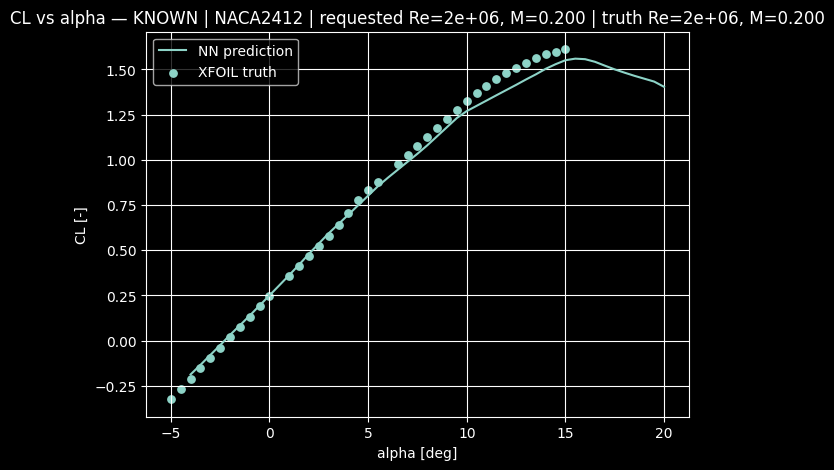

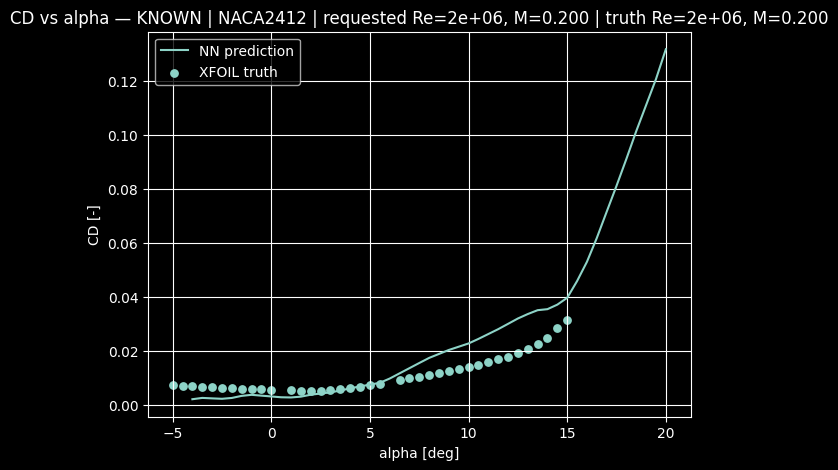

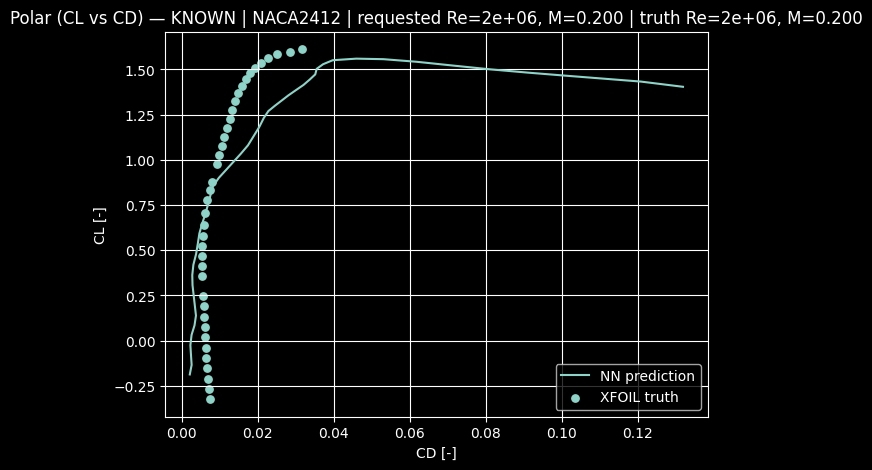

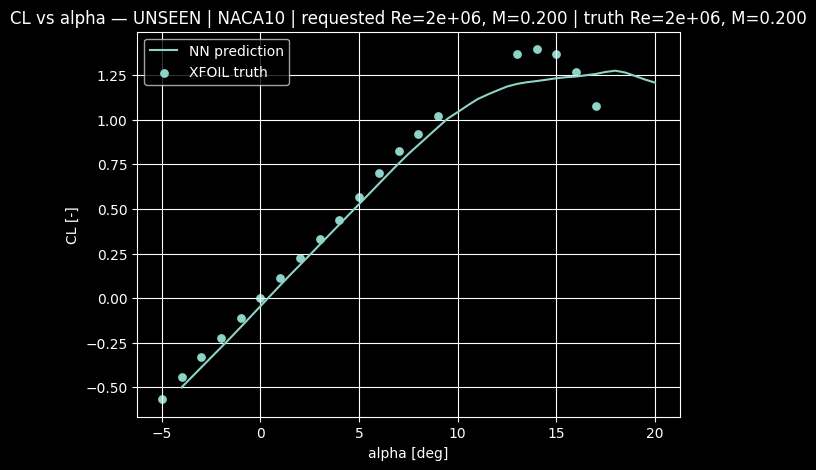

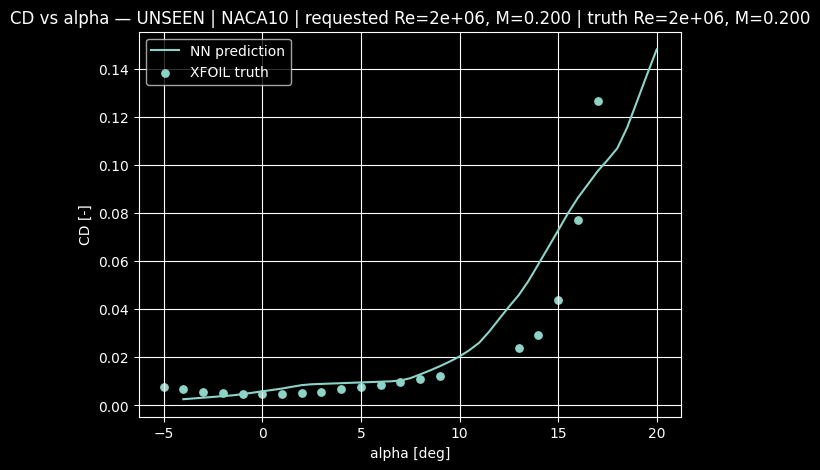

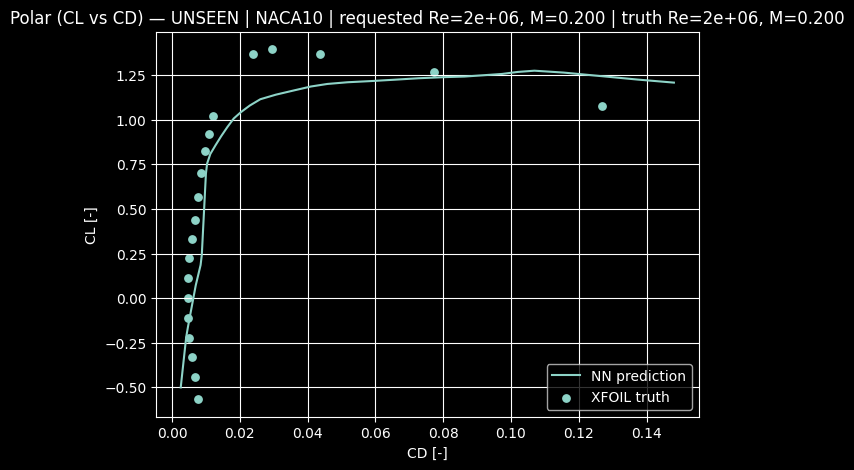

In [9]:
# Optional: save figures into a folder
OUT_DIR = Path("evaluation_plots")
OUT_DIR.mkdir(exist_ok=True)

plot_overlay(df_pred_2412, df_truth_2412, airfoil_name="KNOWN",  save_prefix=str(OUT_DIR / "NACA2412"))
plot_overlay(df_pred_0010, df_truth_0010, airfoil_name="UNSEEN", save_prefix=str(OUT_DIR / "NACA0010"))

## Notes / sanity checks

If the truth and prediction use **different alpha grids**, the overlay remains meaningful:
- NN is drawn as a continuous line over its alpha sweep
- XFOIL truth is drawn as discrete markers at its available alpha points

If you want a point-by-point error curve (e.g., ΔCL(α), ΔCD(α)), add interpolation of one dataset onto the other’s α grid.
